# PART 1: Data Preparation, Incident Segmentation and Model Training

This notebook uses Apache Spark to prepare and analyse the Global Cybersecurity Threats dataset. The analysis includes data cleaning, feature engineering, incident segmentation using K-Means clustering, and the development of a supervised learning model to predict incident resolution time.

## 1. Data Preparation, Cleaning and Feature Engineering

The dataset is first loaded into a Spark DataFrame. Its structure, data types and data quality are examined before cleaning and feature engineering are performed.

## 1.1 Data Preparation

In [0]:
# Load the dataset
cyber_df = spark.table(
    "workspace.default.global_cybersecurity_threats_2015_2024"
)

# Display the dataset size
print("Number of rows:", cyber_df.count())
print("Number of columns:", len(cyber_df.columns))

Number of rows: 3000
Number of columns: 10


In [0]:
# Display the first five rows
display(cyber_df.limit(5))

Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [0]:
# Display the dataset schema
cyber_df.printSchema()

root
 |-- Country: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Attack Type: string (nullable = true)
 |-- Target Industry: string (nullable = true)
 |-- Financial Loss (in Million $): double (nullable = true)
 |-- Number of Affected Users: long (nullable = true)
 |-- Attack Source: string (nullable = true)
 |-- Security Vulnerability Type: string (nullable = true)
 |-- Defense Mechanism Used: string (nullable = true)
 |-- Incident Resolution Time (in Hours): long (nullable = true)



In [0]:
# Display all column names
print("Column names:")
for column in cyber_df.columns:
    print(column)

Column names:
Country
Year
Attack Type
Target Industry
Financial Loss (in Million $)
Number of Affected Users
Attack Source
Security Vulnerability Type
Defense Mechanism Used
Incident Resolution Time (in Hours)


**Observation:**

The dataset contains 3,000 records and 10 variables. The categorical variables are stored as strings, while year, financial loss, affected users, and resolution time are stored as numerical data types. The data structure is suitable for further cleaning, feature engineering, clustering, and regression analysis.

## 1.2 Data Cleaning

Missing values and duplicate records are examined to determine whether data cleaning is required.

In [0]:
# Import Spark SQL functions
from pyspark.sql import functions as F

In [0]:
# Count missing values in each column
missing_values = cyber_df.select([
    F.sum(F.col(column).isNull().cast("int")).alias(column)
    for column in cyber_df.columns
])

display(missing_values)

Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,0,0,0,0,0,0,0,0,0


In [0]:
# Count duplicate records
duplicate_count = cyber_df.count() - cyber_df.dropDuplicates().count()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


**Observation:**

No missing values or duplicate records were found in the dataset. Therefore, no records need to be removed or filled at this stage, and the original 3,000 records can be retained for further analysis.

In [0]:
# Define categorical columns
categorical_columns = [
    "Country",
    "Attack Type",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used"
]

# Display distinct values for each categorical column
for column in categorical_columns:
    print(column)
    cyber_df.select(column).distinct().orderBy(column).show(truncate=False)

Country
+---------+
|Country  |
+---------+
|Australia|
|Brazil   |
|China    |
|France   |
|Germany  |
|India    |
|Japan    |
|Russia   |
|UK       |
|USA      |
+---------+

Attack Type
+-----------------+
|Attack Type      |
+-----------------+
|DDoS             |
|Malware          |
|Man-in-the-Middle|
|Phishing         |
|Ransomware       |
|SQL Injection    |
+-----------------+

Target Industry
+------------------+
|Target Industry   |
+------------------+
|Banking           |
|Education         |
|Government        |
|Healthcare        |
|IT                |
|Retail            |
|Telecommunications|
+------------------+

Attack Source
+-------------+
|Attack Source|
+-------------+
|Hacker Group |
|Insider      |
|Nation-state |
|Unknown      |
+-------------+

Security Vulnerability Type
+---------------------------+
|Security Vulnerability Type|
+---------------------------+
|Social Engineering         |
|Unpatched Software         |
|Weak Passwords             |
|Zero-day  

In [0]:
# Validate the year variable
cyber_df.select(
    F.min("Year").alias("Minimum Year"),
    F.max("Year").alias("Maximum Year"),
    F.count(F.when(F.col("Year").isNull(), 1)).alias("Missing Year")
).show()

+------------+------------+------------+
|Minimum Year|Maximum Year|Missing Year|
+------------+------------+------------+
|        2015|        2024|           0|
+------------+------------+------------+



**Observation:**

The categorical variables contain consistent labels with no noticeable spelling or capitalisation issues. The `Year` variable covers the expected period from 2015 to 2024 without missing values and is already stored as a numerical feature. Therefore, no correction or date conversion was required, and the original values were retained.

In [0]:
# Check the ranges of numerical variables
cyber_df.select(
    F.min("Financial Loss (in Million $)").alias("Minimum Financial Loss"),
    F.max("Financial Loss (in Million $)").alias("Maximum Financial Loss"),
    F.min("Number of Affected Users").alias("Minimum Affected Users"),
    F.max("Number of Affected Users").alias("Maximum Affected Users"),
    F.min("Incident Resolution Time (in Hours)").alias("Minimum Resolution Time"),
    F.max("Incident Resolution Time (in Hours)").alias("Maximum Resolution Time")
).show()

+----------------------+----------------------+----------------------+----------------------+-----------------------+-----------------------+
|Minimum Financial Loss|Maximum Financial Loss|Minimum Affected Users|Maximum Affected Users|Minimum Resolution Time|Maximum Resolution Time|
+----------------------+----------------------+----------------------+----------------------+-----------------------+-----------------------+
|                   0.5|                 99.99|                   424|                999635|                      1|                     72|
+----------------------+----------------------+----------------------+----------------------+-----------------------+-----------------------+



In [0]:
# Count invalid numerical records
cyber_df.select(
    F.sum(
        F.when(F.col("Financial Loss (in Million $)") < 0, 1).otherwise(0)
    ).alias("Invalid Financial Loss"),

    F.sum(
        F.when(F.col("Number of Affected Users") <= 0, 1).otherwise(0)
    ).alias("Invalid Affected Users"),

    F.sum(
        F.when(F.col("Incident Resolution Time (in Hours)") <= 0, 1).otherwise(0)
    ).alias("Invalid Resolution Time")
).show()

+----------------------+----------------------+-----------------------+
|Invalid Financial Loss|Invalid Affected Users|Invalid Resolution Time|
+----------------------+----------------------+-----------------------+
|                     0|                     0|                      0|
+----------------------+----------------------+-----------------------+



**Observation:**

The numerical variables fall within valid ranges. Financial loss ranges from 0.50 to 99.99 million dollars, affected users range from 424 to 999,635, and incident resolution time ranges from 1 to 72 hours. No invalid numerical records were found, so all 3,000 records were retained.

### 1.3 Feature Selection and Engineering

`Financial Loss (in Million $)` and `Number of Affected Users` are selected for incident segmentation. These variables represent the financial severity and the scale of impact of each cybersecurity incident. The selected variables are assembled into a feature vector and standardised before K-Means clustering.

In [0]:
# Import feature engineering tools
from pyspark.ml.feature import VectorAssembler, StandardScaler

In [0]:
# Combine the selected variables into a feature vector
vec_assembler = VectorAssembler(
    inputCols=[
        "Financial Loss (in Million $)",
        "Number of Affected Users"
    ],
    outputCol="features"
)

df_vector = vec_assembler.transform(cyber_df)

# Display the assembled features
df_vector.select(
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "features"
).show(5, truncate=False)

+-----------------------------+------------------------+----------------+
|Financial Loss (in Million $)|Number of Affected Users|features        |
+-----------------------------+------------------------+----------------+
|80.53                        |773169                  |[80.53,773169.0]|
|62.19                        |295961                  |[62.19,295961.0]|
|38.65                        |605895                  |[38.65,605895.0]|
|41.44                        |659320                  |[41.44,659320.0]|
|74.41                        |810682                  |[74.41,810682.0]|
+-----------------------------+------------------------+----------------+
only showing top 5 rows


In [0]:
# Standardise the selected features
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vector)
scaled_df = scaler_model.transform(df_vector)

# Display the standardised features
scaled_df.select(
    "features",
    "scaledFeatures"
).show(5, truncate=False)

+----------------+-----------------------------------------+
|features        |scaledFeatures                           |
+----------------+-----------------------------------------+
|[80.53,773169.0]|[1.0432634092412303,0.9259884149477835]  |
|[62.19,295961.0]|[0.40626797642099893,-0.7198737520495451]|
|[38.65,605895.0]|[-0.4113368484747614,0.34907028255622435]|
|[41.44,659320.0]|[-0.31443296311116026,0.5333299476746471]|
|[74.41,810682.0]|[0.8307000477984922,1.0553685331993023]  |
+----------------+-----------------------------------------+
only showing top 5 rows


**Observation:**

Financial loss and number of affected users were assembled into a single feature vector. Standardisation was applied because the two variables have substantially different numerical scales, allowing both variables to contribute fairly to the clustering process.

## 2. Incident Segmentation Using K-Means Clustering

K-Means clustering is used to group cybersecurity incidents into distinct risk profiles. Different values of K are evaluated to determine an appropriate number of clusters.

## 2.1 Determine the Number of Clusters

In [0]:
# Import clustering and evaluation tools
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [0]:
# Create lists to store the evaluation results
k_values = []
training_costs = []
silhouette_scores = []

# Create the clustering evaluator
evaluator = ClusteringEvaluator(
    featuresCol="scaledFeatures",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

# Train K-Means models for K = 2 to 10
for k in range(2, 11):
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaledFeatures",
        predictionCol="prediction"
    )

    model = kmeans.fit(scaled_df)
    predictions = model.transform(scaled_df)

    training_cost = model.summary.trainingCost
    silhouette_score = evaluator.evaluate(predictions)

    k_values.append(k)
    training_costs.append(training_cost)
    silhouette_scores.append(silhouette_score)

    print(
        f"K = {k}, "
        f"Training Cost = {training_cost:.2f}, "
        f"Silhouette Score = {silhouette_score:.4f}"
    )

K = 2, Training Cost = 3741.13, Silhouette Score = 0.5077
K = 3, Training Cost = 2333.76, Silhouette Score = 0.5504
K = 4, Training Cost = 1484.79, Silhouette Score = 0.5939
K = 5, Training Cost = 1266.12, Silhouette Score = 0.5558
K = 6, Training Cost = 1086.44, Silhouette Score = 0.5290
K = 7, Training Cost = 913.60, Silhouette Score = 0.5173
K = 8, Training Cost = 797.18, Silhouette Score = 0.5260
K = 9, Training Cost = 716.86, Silhouette Score = 0.5209
K = 10, Training Cost = 605.62, Silhouette Score = 0.5376


In [0]:
# Import the plotting library
import matplotlib.pyplot as plt

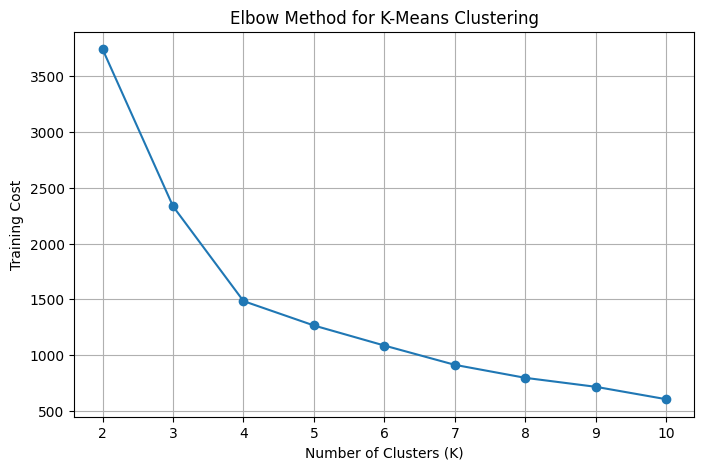

In [0]:
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, training_costs, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Training Cost")
plt.title("Elbow Method for K-Means Clustering")
plt.xticks(k_values)
plt.grid()
plt.show()

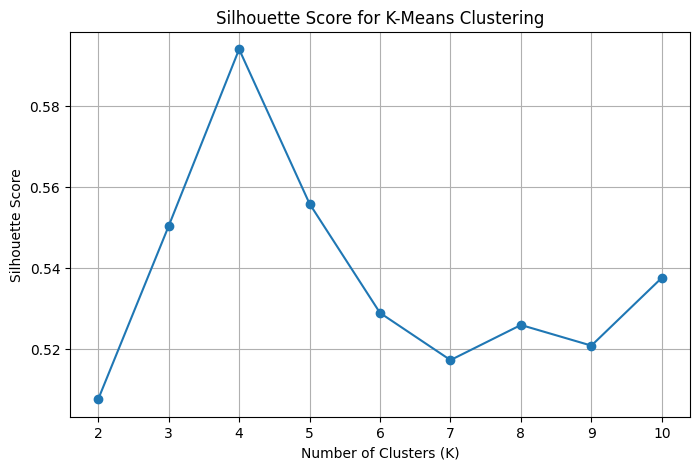

In [0]:
# Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means Clustering")
plt.xticks(k_values)
plt.grid()
plt.show()

**Observation:**

The training cost decreases sharply from K = 2 to K = 4 and becomes more gradual after K = 4, indicating an elbow at four clusters. K = 4 also achieves the highest Silhouette Score of 0.5939. Therefore, four clusters were selected for the final K-Means model.

## 2.2 Final K-Means Model

The final K-Means model is trained using four clusters based on the Elbow Method and Silhouette Score results.

In [0]:
# Train the final K-Means model
kmeans = KMeans(
    k=4,
    seed=42,
    featuresCol="scaledFeatures"
)

kmeans_model = kmeans.fit(scaled_df)

# Assign each incident to a cluster
clustered_df = kmeans_model.transform(scaled_df)

In [0]:
# Display the clustering results
clustered_df.select(
    "Country",
    "Attack Type",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "prediction"
).show(10, truncate=False)

+-------+-----------------+-----------------------------+------------------------+----------+
|Country|Attack Type      |Financial Loss (in Million $)|Number of Affected Users|prediction|
+-------+-----------------+-----------------------------+------------------------+----------+
|China  |Phishing         |80.53                        |773169                  |3         |
|China  |Ransomware       |62.19                        |295961                  |0         |
|India  |Man-in-the-Middle|38.65                        |605895                  |1         |
|UK     |Ransomware       |41.44                        |659320                  |1         |
|Germany|Man-in-the-Middle|74.41                        |810682                  |3         |
|Germany|Man-in-the-Middle|98.24                        |285201                  |0         |
|Germany|DDoS             |33.26                        |431262                  |2         |
|France |SQL Injection    |59.23                        |909

In [0]:
# Count the incidents in each cluster
clustered_df.groupBy("prediction") \
    .count() \
    .orderBy("prediction") \
    .show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|  736|
|         1|  715|
|         2|  761|
|         3|  788|
+----------+-----+



In [0]:
# Evaluate the final clustering model
final_silhouette = evaluator.evaluate(clustered_df)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.5939


**Observation:**

The final model produced four relatively balanced clusters containing between 715 and 788 incidents. The Silhouette Score of 0.5939 indicates that the incidents have a reasonable level of separation between clusters.

### 2.3 Cluster Analysis and Risk Profile Identification

Each cluster is analysed based on its average financial loss, average number of affected users, and attack-type distribution. The results are then used to assign a descriptive cyber-risk-profile name to each cluster.

In [0]:
# Calculate the summary statistics for each cluster
cluster_summary = clustered_df.groupBy("prediction").agg(
    F.count("*").alias("Incident Count"),
    F.round(
        F.avg("Financial Loss (in Million $)"), 2
    ).alias("Average Financial Loss (Million $)"),
    F.round(
        F.avg("Number of Affected Users"), 2
    ).alias("Average Affected Users")
).orderBy("prediction")

display(cluster_summary)

prediction,Incident Count,Average Financial Loss (Million $),Average Affected Users
0,736,75.49,248509.75
1,715,23.65,759248.26
2,761,26.51,257183.05
3,788,74.66,751992.92


In [0]:
# Count the total incidents in each cluster
cluster_totals = clustered_df.groupBy("prediction").agg(
    F.count("*").alias("Cluster Total")
)

In [0]:
# Count the attack types in each cluster
attack_type_summary = clustered_df.groupBy(
    "prediction",
    "Attack Type"
).agg(
    F.count("*").alias("Attack Count")
)

In [0]:
# Calculate the percentage of each attack type
attack_type_summary = attack_type_summary.join(
    cluster_totals,
    on="prediction",
    how="left"
).withColumn(
    "Percentage",
    F.round(
        F.col("Attack Count") / F.col("Cluster Total") * 100,
        2
    )
).orderBy(
    "prediction",
    F.desc("Attack Count")
)

display(attack_type_summary)

prediction,Attack Type,Attack Count,Cluster Total,Percentage
0,DDoS,147,736,19.97
0,Phishing,133,736,18.07
0,Malware,122,736,16.58
0,SQL Injection,115,736,15.63
0,Ransomware,114,736,15.49
0,Man-in-the-Middle,105,736,14.27
1,Phishing,125,715,17.48
1,DDoS,122,715,17.06
1,Malware,120,715,16.78
1,Ransomware,117,715,16.36


In [0]:
# Assign descriptive risk profile names
clustered_df = clustered_df.withColumn(
    "Risk Profile",
    F.when(
        F.col("prediction") == 0,
        "High-Cost Lower-Reach Incidents"
    ).when(
        F.col("prediction") == 1,
        "Wide-Reach Lower-Cost Incidents"
    ).when(
        F.col("prediction") == 2,
        "Lower-Impact Cyber Incidents"
    ).when(
        F.col("prediction") == 3,
        "High-Cost Wide-Reach Incidents"
    )
)

**Observation:**

The incidents were clustered using two standardised variables: financial loss and number of affected users. These variables represent the economic severity and the scale of user impact of each cybersecurity incident. Four clusters were selected because K = 4 formed a clear elbow in the training-cost curve and achieved the highest Silhouette Score of 0.5939.

The cluster profiles were identified by comparing their average financial loss and average number of affected users. 

Cluster 0 was labelled **High-Cost Lower-Reach Incidents** because it has a high average financial loss of 75.49 million dollars but a relatively lower average user impact of 248,509.75 users. 

Cluster 1 was labelled **Wide-Reach Lower-Cost Incidents** because it affects a large average number of users, 759,248.26, while its average financial loss is comparatively lower at 23.65 million dollars.

Cluster 2 was labelled **Lower-Impact Cyber Incidents** because it records both a relatively low average financial loss of 26.51 million dollars and a lower average number of affected users of 257,183.05. 

Cluster 3 was labelled **High-Cost Wide-Reach Incidents** because it combines a high average financial loss of 74.66 million dollars with a large average user impact of 751,992.92 users, making it the most severe overall risk profile.

The attack-type distribution was also examined for each cluster. However, the percentages were relatively balanced, and no single attack type strongly dominated any cluster. Therefore, the final risk-profile names were mainly determined by financial severity and user impact, while the attack-type results indicate that each profile contains a mixture of cybersecurity threats.

## 3. Predictive Model Training and Evaluation

A supervised regression model is developed using Spark ML to predict the incident resolution time from the characteristics of each cybersecurity incident.

## 3.1 Feature Selection and Data Splitting

The incident resolution time is selected as the target variable. The remaining original incident characteristics are selected as input features because they describe the location, attack characteristics, financial impact, user impact, vulnerability, and defence mechanism of each incident.

In [0]:
# Define the target variable
label_column = "Incident Resolution Time (in Hours)"

# Define categorical input features
categorical_columns = [
    "Country",
    "Attack Type",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used"
]

# Define numerical input features
numerical_columns = [
    "Year",
    "Financial Loss (in Million $)",
    "Number of Affected Users"
]

# Select the variables required for prediction
selected_columns = (
    categorical_columns
    + numerical_columns
    + [label_column]
)

model_df = cyber_df.select(*selected_columns)

In [0]:
# Display the selected variables
display(model_df.limit(5))

Country,Attack Type,Target Industry,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
China,Phishing,Education,Hacker Group,Unpatched Software,VPN,2019,80.53,773169,63
China,Ransomware,Retail,Hacker Group,Unpatched Software,Firewall,2019,62.19,295961,71
India,Man-in-the-Middle,IT,Hacker Group,Weak Passwords,VPN,2017,38.65,605895,20
UK,Ransomware,Telecommunications,Nation-state,Social Engineering,AI-based Detection,2024,41.44,659320,7
Germany,Man-in-the-Middle,IT,Insider,Social Engineering,VPN,2018,74.41,810682,68


In [0]:
# Split the dataset into training and testing sets
train_df, test_df = model_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

# Display the number of records
print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 2405
Testing records: 595


**Observation:**

The selected dataset contains nine input features and one target variable. The data was divided into 2,405 training records and 595 testing records using an approximately 80:20 split. A fixed random seed was used to ensure that the split is reproducible.

## 3.2 Feature Encoding and Assembly

The categorical variables are converted into numerical representations using `StringIndexer` and `OneHotEncoder`. The encoded categorical features and original numerical features are then combined into a single feature vector for model training.

In [0]:
# Import feature transformation tools
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

In [0]:
# Create a StringIndexer for each categorical feature
indexers = [
    StringIndexer(
        inputCol=column,
        outputCol=column + "_index",
        handleInvalid="keep"
    )
    for column in categorical_columns
]

In [0]:
# Define the indexed and encoded column names
indexed_columns = [
    column + "_index"
    for column in categorical_columns
]

encoded_columns = [
    column + "_encoded"
    for column in categorical_columns
]

# Convert indexed categories into binary vectors
encoder = OneHotEncoder(
    inputCols=indexed_columns,
    outputCols=encoded_columns,
    handleInvalid="keep"
)

In [0]:
# Combine encoded categorical features and numerical features
assembler = VectorAssembler(
    inputCols=encoded_columns + numerical_columns,
    outputCol="model_features"
)

In [0]:
# Display the feature transformation stages
print("Categorical features:", categorical_columns)
print("Encoded features:", encoded_columns)
print("Numerical features:", numerical_columns)

Categorical features: ['Country', 'Attack Type', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']
Encoded features: ['Country_encoded', 'Attack Type_encoded', 'Target Industry_encoded', 'Attack Source_encoded', 'Security Vulnerability Type_encoded', 'Defense Mechanism Used_encoded']
Numerical features: ['Year', 'Financial Loss (in Million $)', 'Number of Affected Users']


**Observation:**

Six categorical features were prepared for indexing and one-hot encoding, while three numerical features were retained in their original numerical form. These transformed variables will be combined into one feature vector for supervised model training.

## 3.3 Random Forest Regression Model

A Random Forest Regressor is used to predict incident resolution time. The model can capture non-linear relationships between the incident characteristics and the target variable. All feature-transformation stages and the regression model are combined in a Spark ML Pipeline.

In [0]:
# Import Random Forest Regressor
from pyspark.ml.regression import RandomForestRegressor

In [0]:
# Convert the target variable to double
train_df = train_df.withColumn(
    label_column,
    F.col(label_column).cast("double")
)

test_df = test_df.withColumn(
    label_column,
    F.col(label_column).cast("double")
)

In [0]:
# Define the Random Forest Regressor
rf = RandomForestRegressor(
    featuresCol="model_features",
    labelCol=label_column,
    predictionCol="prediction",
    numTrees=100,
    seed=42
)

In [0]:
# Build the complete machine learning pipeline
rf_pipeline = Pipeline(
    stages=indexers + [
        encoder,
        assembler,
        rf
    ]
)

In [0]:
# Train the Random Forest model
rf_pipeline_model = rf_pipeline.fit(train_df)

In [0]:
# Make predictions on the testing dataset
predictions_df = rf_pipeline_model.transform(test_df)

In [0]:
# Display the actual and predicted resolution times
predictions_df.select(
    "Attack Type",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    label_column,
    F.round("prediction", 2).alias("Predicted Resolution Time")
).show(10, truncate=False)

+-----------+-----------------------------+------------------------+-----------------------------------+-------------------------+
|Attack Type|Financial Loss (in Million $)|Number of Affected Users|Incident Resolution Time (in Hours)|Predicted Resolution Time|
+-----------+-----------------------------+------------------------+-----------------------------------+-------------------------+
|DDoS       |31.74                        |724207                  |54.0                               |33.32                    |
|DDoS       |54.63                        |22739                   |44.0                               |36.48                    |
|DDoS       |93.39                        |630087                  |72.0                               |34.98                    |
|DDoS       |76.25                        |900661                  |64.0                               |37.6                     |
|DDoS       |13.96                        |479025                  |54.0           

## 3.4 Model Performance Evaluation

The Random Forest model is evaluated using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²). These metrics measure the prediction error and the model's ability to explain variations in incident resolution time.

In [0]:
# Import the regression evaluator
from pyspark.ml.evaluation import RegressionEvaluator

In [0]:
# Calculate RMSE
rmse_evaluator = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction",
    metricName="rmse"
)

rmse = rmse_evaluator.evaluate(predictions_df)

# Calculate MAE
mae_evaluator = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction",
    metricName="mae"
)

mae = mae_evaluator.evaluate(predictions_df)

# Calculate R-squared
r2_evaluator = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction",
    metricName="r2"
)

r2 = r2_evaluator.evaluate(predictions_df)

# Display the evaluation results
print("Random Forest Results")
print("RMSE:", round(rmse, 4))
print("MAE: ", round(mae, 4))
print("R²:  ", round(r2, 4))

Random Forest Results
RMSE: 20.8996
MAE:  18.2605
R²:   -0.0217


To further evaluate the model’s performance, a mean baseline test was conducted for comparison.


In [0]:
# Create a mean baseline using the training-set average
training_mean = train_df.select(
    F.avg(label_column).alias("Training Mean")
).first()["Training Mean"]

baseline_df = test_df.withColumn(
    "baseline_prediction",
    F.lit(training_mean)
)

# Evaluate the mean baseline
baseline_rmse = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="baseline_prediction",
    metricName="rmse"
).evaluate(baseline_df)

baseline_mae = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="baseline_prediction",
    metricName="mae"
).evaluate(baseline_df)

baseline_r2 = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="baseline_prediction",
    metricName="r2"
).evaluate(baseline_df)

# Compare the two models
model_comparison = spark.createDataFrame([
    ("Mean Baseline", round(baseline_rmse, 4),
     round(baseline_mae, 4), round(baseline_r2, 4)),

    ("Random Forest", round(rmse, 4),
     round(mae, 4), round(r2, 4))
], ["Model", "RMSE", "MAE", "R²"])

display(model_comparison)

Model,RMSE,MAE,R²
Mean Baseline,20.7255,18.1382,-0.0048
Random Forest,20.8996,18.2605,-0.0217


**Observation:**

The Random Forest model achieved an RMSE of 20.8996 hours and an MAE of 18.2605 hours, indicating that the predicted resolution times differed from the actual values by approximately 18 hours on average. Its R² value of -0.0217 suggests that the model explained very little of the variation in incident resolution time.

For comparison, the mean baseline produced a slightly lower RMSE of 20.7255 and MAE of 18.1382, with an R² value of -0.0048. This shows that the Random Forest did not provide a meaningful improvement over a simple mean-based prediction. The result may indicate that the available incident characteristics have only a weak or inconsistent relationship with resolution time, which limits the model’s predictive performance.

## 3.5 Residual Analysis

Residuals are calculated as the difference between the actual and predicted resolution times. A positive residual indicates under-prediction, while a negative residual indicates over-prediction.

In [0]:
# Calculate residuals and absolute errors
predictions_df = predictions_df.withColumn(
    "residual",
    F.col(label_column) - F.col("prediction")
).withColumn(
    "absolute_error",
    F.abs(F.col("residual"))
)

# Display the residual results
predictions_df.select(
    "Attack Type",
    label_column,
    F.round("prediction", 2).alias("Predicted Resolution Time"),
    F.round("residual", 2).alias("Residual"),
    F.round("absolute_error", 2).alias("Absolute Error")
).show(10, truncate=False)

+-----------+-----------------------------------+-------------------------+--------+--------------+
|Attack Type|Incident Resolution Time (in Hours)|Predicted Resolution Time|Residual|Absolute Error|
+-----------+-----------------------------------+-------------------------+--------+--------------+
|DDoS       |54.0                               |33.32                    |20.68   |20.68         |
|DDoS       |44.0                               |36.48                    |7.52    |7.52          |
|DDoS       |72.0                               |34.98                    |37.02   |37.02         |
|DDoS       |64.0                               |37.6                     |26.4    |26.4          |
|DDoS       |54.0                               |37.04                    |16.96   |16.96         |
|DDoS       |72.0                               |36.2                     |35.8    |35.8          |
|DDoS       |14.0                               |36.03                    |-22.03  |22.03         |


In [0]:
# Calculate the overall residual statistics
residual_summary = predictions_df.select(
    F.round(
        F.avg("residual"), 4
    ).alias("Mean Residual"),

    F.round(
        F.avg("absolute_error"), 4
    ).alias("Mean Absolute Error"),

    F.round(
        F.min("residual"), 2
    ).alias("Minimum Residual"),

    F.round(
        F.max("residual"), 2
    ).alias("Maximum Residual")
)

display(residual_summary)

Mean Residual,Mean Absolute Error,Minimum Residual,Maximum Residual
1.4818,18.2605,-37.08,37.6


In [0]:
# Convert the required columns to Pandas for plotting
residual_pd = predictions_df.select(
    "prediction",
    "residual"
).toPandas()

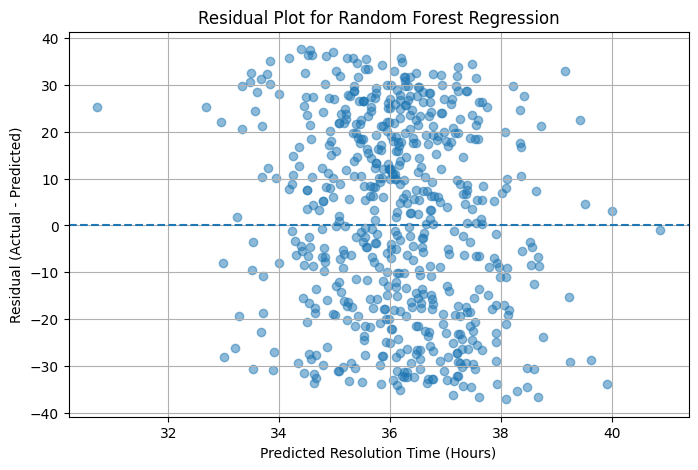

In [0]:
# Plot residuals against predicted resolution time
plt.figure(figsize=(8, 5))

plt.scatter(
    residual_pd["prediction"],
    residual_pd["residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Resolution Time (Hours)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot for Random Forest Regression")
plt.grid()
plt.show()

**Overall Residual Reflection:**

The residuals are distributed on both sides of the zero line, indicating that the model does not consistently over-predict or under-predict all incidents. The mean residual is 1.4818 hours, which shows a slight overall tendency to under-predict resolution time. However, this average bias is small compared with the mean absolute error of 18.2605 hours.

The predicted values are concentrated mainly between approximately 34 and 39 hours, while the residuals range from -37.08 to 37.60 hours. This indicates that the model tends to predict values close to the average resolution time. As a result, incidents with long actual resolution times are often under-predicted, while incidents with short actual resolution times are often over-predicted. Therefore, the residuals do not show a strong one-direction bias, but they are not completely random because the model demonstrates a systematic tendency towards the mean.

### 3.5.1 Compare Errors by Attack Type

"Are our prediction errors larger for Ransomware attacks compared to Phishing?"

In [0]:
# Calculate prediction errors for each attack type
attack_error_summary = predictions_df.groupBy(
    "Attack Type"
).agg(
    F.count("*").alias("Incident Count"),
    F.round(
        F.avg("absolute_error"), 4
    ).alias("Mean Absolute Error"),
    F.round(
        F.avg("residual"), 4
    ).alias("Mean Residual")
).orderBy(
    F.desc("Mean Absolute Error")
)

display(attack_error_summary)

Attack Type,Incident Count,Mean Absolute Error,Mean Residual
Phishing,105,19.4782,1.1406
Ransomware,106,19.1143,3.5164
DDoS,113,18.5468,2.4705
SQL Injection,108,18.1185,1.613
Man-in-the-Middle,75,17.7342,-0.1096
Malware,88,16.0344,-0.636


**Observation:**

Prediction accuracy also varies slightly between attack types. Phishing recorded the highest mean absolute error of 19.4782 hours, compared with 19.1143 hours for Ransomware. Therefore, the prediction errors were not larger for Ransomware than for Phishing. However, Ransomware had a higher positive mean residual of 3.5164 hours, indicating that the model tended to under-predict Ransomware resolution times more strongly than Phishing resolution times.

### 3.5.2 Analyse Very High Financial Loss Incidents

"Does the model consistently under-predict resolution time for incidents with very
high financial loss?"

In [0]:
# Find the 75th percentile of financial loss
high_loss_threshold = predictions_df.select(
    F.percentile_approx(
        "Financial Loss (in Million $)",
        0.75
    ).alias("High Loss Threshold")
).first()["High Loss Threshold"]

print(
    "Very High Financial Loss Threshold:",
    high_loss_threshold,
    "million dollars"
)

Very High Financial Loss Threshold: 75.25 million dollars


In [0]:
# Group incidents according to financial loss
loss_analysis_df = predictions_df.withColumn(
    "Financial Loss Group",
    F.when(
        F.col("Financial Loss (in Million $)") >= high_loss_threshold,
        "Very High Financial Loss"
    ).otherwise(
        "Other Incidents"
    )
)

# Compare prediction errors between the two groups
loss_error_summary = loss_analysis_df.groupBy(
    "Financial Loss Group"
).agg(
    F.count("*").alias("Incident Count"),
    F.round(
        F.avg("residual"), 4
    ).alias("Mean Residual"),
    F.round(
        F.avg("absolute_error"), 4
    ).alias("Mean Absolute Error"),
    F.round(
        F.avg(
            F.when(F.col("residual") > 0, 1).otherwise(0)
        ) * 100,
        2
    ).alias("Under-Prediction Percentage")
)

display(loss_error_summary)

Financial Loss Group,Incident Count,Mean Residual,Mean Absolute Error,Under-Prediction Percentage
Very High Financial Loss,149,-0.2733,19.0519,46.31
Other Incidents,446,2.0681,17.9961,55.38


**Observation:**

For incidents with very high financial loss, the mean residual was -0.2733 hours and only 46.31% of the incidents were under-predicted. This shows that the model did not consistently under-predict incidents with very high financial loss. Nevertheless, their mean absolute error of 19.0519 hours was slightly higher than the 17.9961 hours recorded for other incidents, indicating that high-loss incidents were somewhat more difficult for the model to predict accurately.


##  Deployment Model Export

The deployment model was designed to remain consistent with the Spark model used in Part I. It was trained using the same cleaned dataset, the same input features, the same target variable, and the same Random Forest regression approach. The same categorical and numerical information was also retained during preprocessing. The main difference is that the deployment version was implemented as a scikit-learn pipeline and exported as a Joblib file so that it could be loaded efficiently by FastAPI and deployed on Render. Therefore, the two models follow the same modelling design, while the Joblib version is used specifically for web deployment.

In [0]:
import joblib
import platform
import numpy as np
import pandas as pd
import scipy
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# Define the features used by the deployment model
deployment_categorical_columns = [
    "Country",
    "Attack Type",
    "Target Industry",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used"
]

deployment_numerical_columns = [
    "Year",
    "Financial Loss (in Million $)",
    "Number of Affected Users"
]

deployment_label_column = (
    "Incident Resolution Time (in Hours)"
)

deployment_feature_columns = (
    deployment_categorical_columns
    + deployment_numerical_columns
)


# Convert the cleaned Spark DataFrame to Pandas
deployment_df = cyber_df.select(
    *deployment_feature_columns,
    deployment_label_column
).toPandas()


X_deployment = deployment_df[
    deployment_feature_columns
].copy()

y_deployment = deployment_df[
    deployment_label_column
].astype(float)


# Preprocess categorical and numerical features
deployment_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            deployment_categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            deployment_numerical_columns
        )
    ]
)


# Create the complete deployment pipeline
deployment_model = Pipeline(
    steps=[
        (
            "preprocessor",
            deployment_preprocessor
        ),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# Train the deployment model
deployment_model.fit(
    X_deployment,
    y_deployment
)


# Save the model to the Databricks Volume
artifact_dir = (
    "/Volumes/workspace/default/"
    "cys404_artifacts"
)

model_path = f"{artifact_dir}/model.joblib"

joblib.dump(
    deployment_model,
    model_path,
    compress=3
)


print("Deployment model saved successfully.")
print("Model path:", model_path)
print("Number of training records:", len(X_deployment))

Deployment model saved successfully.
Model path: /Volumes/workspace/default/cys404_artifacts/model.joblib
Number of training records: 3000


In [0]:
requirements_content = f"""fastapi==0.116.1
uvicorn[standard]==0.35.0
pandas=={pd.__version__}
numpy=={np.__version__}
scipy=={scipy.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
"""

requirements_path = (
    f"{artifact_dir}/requirements.txt"
)

with open(requirements_path, "w") as file:
    file.write(requirements_content)


python_version_path = (
    f"{artifact_dir}/python_version.txt"
)

with open(python_version_path, "w") as file:
    file.write(platform.python_version())


print("Requirements saved to:", requirements_path)
print("Python version:", platform.python_version())
print()
print(requirements_content)

Requirements saved to: /Volumes/workspace/default/cys404_artifacts/requirements.txt
Python version: 3.12.3

fastapi==0.116.1
uvicorn[standard]==0.35.0
pandas==2.2.3
numpy==2.1.3
scipy==1.15.3
scikit-learn==1.6.1
joblib==1.4.2



In [0]:
display(dbutils.fs.ls(artifact_dir))

path,name,size,modificationTime
dbfs:/Volumes/workspace/default/cys404_artifacts/clustered_incidents.csv,clustered_incidents.csv,350229,1784377662000
dbfs:/Volumes/workspace/default/cys404_artifacts/model.joblib,model.joblib,4418621,1784437755000
dbfs:/Volumes/workspace/default/cys404_artifacts/python_version.txt,python_version.txt,6,1784437756000
dbfs:/Volumes/workspace/default/cys404_artifacts/requirements.txt,requirements.txt,118,1784437756000
